<a href="https://colab.research.google.com/github/iddadobroc/Sam_Altman_Plots/blob/main/Sam_Altman_Portfolio_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving sam_altman.csv to sam_altman.csv


In [2]:
import pandas as pd

df = pd.read_csv("sam_altman.csv")

In [3]:
df.head()

,Name,HQ country,Investors names,Each investor type,Lead investors,Total funding (USD M),Last round,Last funding date,First funding date,Launch year,Industries,Sub industries,Employees latest number,Valuation,Total rounds number
0,Stripe,United States,American Express Ventures;Kleiner Perkins;Sequ...,"corporate_venture_fund;private_equity,venture_...",E1 ventures;Ventioneers,8735124999,SECONDARY,feb/2026,jun/2009,2009,fintech,payments,14184,159000000000,23
1,Oklo,United States,Y Combinator;MassChallenge;Trust Ventures;DCVC...,accelerator;accelerator;venture_capital;ventur...,Sam Altman,295000,POST IPO EQUITY,jan/2026,oct/2013,2013,energy,clean energy,249,18480000000,9
2,OpenAI,United States,Microsoft;Elon Musk;Greg Brockman;Reid Hoffman...,corporate;angel;angel;angel;angel;angel;corpor...,Coatue Management;Dragoneer Investment Group;T...,69950000000,LATE VC,dec/2025,dec/2015,2015,enterprise software,NaN,7247,500000000000,17
3,Boom Supersonic,United States,Y Combinator;Emerson Collective;SV Angel;Japan...,accelerator;family_office;venture_capital;corp...,Darsana Capital Partners,709835001,LATE VC,dec/2025,nov/2015,2014,transportation;engineering and manufacturing e...,vehicle production,306,1200000000-1800000000,19
4,Opendoor,United States,Notable Capital;Khosla Ventures;Thrive Capital...,venture_capital;venture_capital;venture_capita...,NaN,2120950000,POST IPO EQUITY,nov/2025,jul/2014,2014,real estate,"search, buy & rent",1387,7340000000,13


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Name                     25 non-null     object
 1   HQ country               25 non-null     object
 2   Investors names          25 non-null     object
 3   Each investor type       25 non-null     object
 4   Lead investors           16 non-null     object
 5   Total funding (USD M)    25 non-null     int64 
 6   Last round               25 non-null     object
 7   Last funding date        25 non-null     object
 8   First funding date       25 non-null     object
 9   Launch year              25 non-null     int64 
 10  Industries               25 non-null     object
 11  Sub industries           19 non-null     object
 12  Employees latest number  25 non-null     int64 
 13  Valuation                25 non-null     object
 14  Total rounds number      25 non-null     int

In [5]:
df.columns

Index(['Name', 'HQ country', 'Investors names', 'Each investor type',
       'Lead investors', 'Total funding (USD M)', 'Last round',
       'Last funding date', 'First funding date', 'Launch year', 'Industries',
       'Sub industries', 'Employees latest number', 'Valuation',
       'Total rounds number'],
      dtype='object')

In [6]:
import numpy as np

def clean_valuation(val):
    if isinstance(val, str):
        if "-" in val:
            parts = val.split("-")
            return np.mean([float(p) for p in parts])
        else:
            return float(val)
    return val

df["Valuation_clean"] = df["Valuation"].apply(clean_valuation)

# Convertiamo in miliardi
df["Valuation_B"] = df["Valuation_clean"] / 1e9

In [7]:
df[["Name", "Valuation", "Valuation_B"]].head()

,Name,Valuation,Valuation_B
0,Stripe,159000000000,159.00
1,Oklo,18480000000,18.48
2,OpenAI,500000000000,500.00
3,Boom Supersonic,1200000000-1800000000,1.50
4,Opendoor,7340000000,7.34


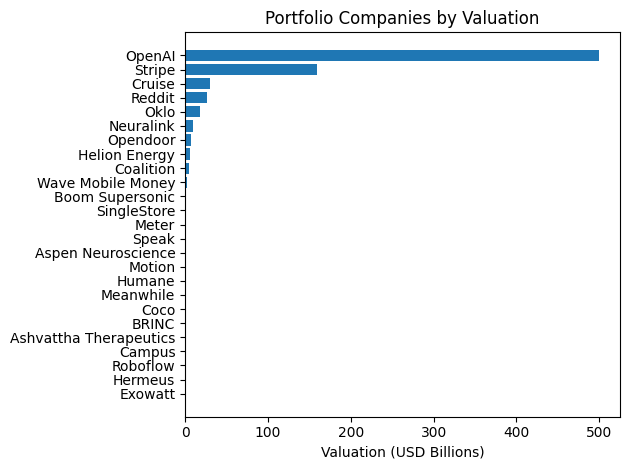

In [8]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values("Valuation_B", ascending=True)

plt.figure()
plt.barh(df_sorted["Name"], df_sorted["Valuation_B"])
plt.xlabel("Valuation (USD Billions)")
plt.title("Portfolio Companies by Valuation")
plt.tight_layout()
plt.show()

In [55]:
import plotly.express as px


valuation_df = df.sort_values("Valuation_B", ascending=True)

fig = px.bar(
    valuation_df,
    x="Valuation_B",
    y="Name",
    orientation="h",
    title="Portfolio Companies by Valuation"
)

fig.update_traces(marker_color="#1f77b4")

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    xaxis_title="Valuation (USD Billions)",
    yaxis_title="",
    height=800
)

fig.show()

In [46]:
df["Valuation_clean"] = (
    df["Valuation"]
      .str.replace(",", "")
      .str.split("-")
      .str[0]
      .astype(float)
)

df["Valuation_B"] = df["Valuation_clean"] / 1e9

In [47]:
valuation_df = df.sort_values("Valuation_B", ascending=True)

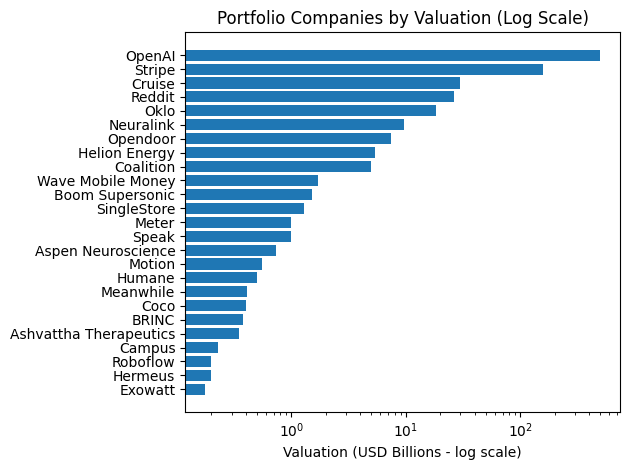

In [10]:
plt.figure()
plt.barh(df_sorted["Name"], df_sorted["Valuation_B"])
plt.xscale("log")
plt.xlabel("Valuation (USD Billions - log scale)")
plt.title("Portfolio Companies by Valuation (Log Scale)")
plt.tight_layout()
plt.show()

In [53]:
valuation_df["Highlight"] = valuation_df["Name"].apply(
    lambda x: "OpenAI" if x == "OpenAI" else "Other"
)

fig = px.bar(
    valuation_df,
    x="Valuation_B",
    y="Name",
    orientation="h",
    color="Highlight",
    color_discrete_map={
        "OpenAI": "#FF4B4B",
        "Other": "#4C78A8"
    },
    title="Portfolio Companies by Valuation"
)

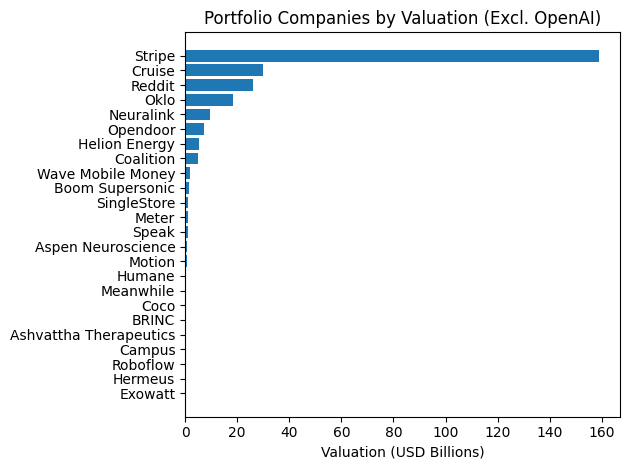

In [11]:
df_no_openai = df[df["Name"] != "OpenAI"]

df_sorted_no = df_no_openai.sort_values("Valuation_B", ascending=True)

plt.figure()
plt.barh(df_sorted_no["Name"], df_sorted_no["Valuation_B"])
plt.xlabel("Valuation (USD Billions)")
plt.title("Portfolio Companies by Valuation (Excl. OpenAI)")
plt.tight_layout()
plt.show()

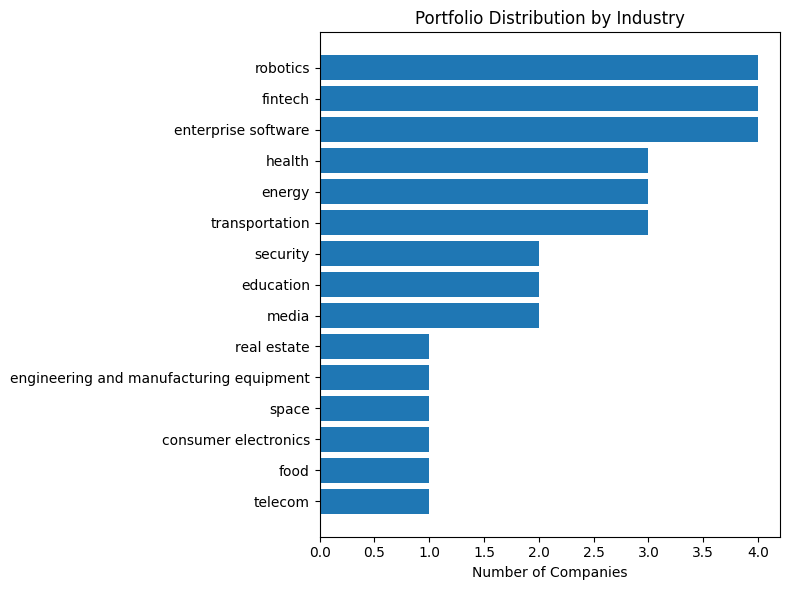

In [14]:
import matplotlib.pyplot as plt

sector_counts = sector_counts.sort_values()

plt.figure(figsize=(8,6))
plt.barh(sector_counts.index, sector_counts.values)
plt.xlabel("Number of Companies")
plt.title("Portfolio Distribution by Industry")
plt.tight_layout()
plt.show()

In [39]:
import plotly.express as px

# Splittiamo temporaneamente senza toccare df
industries_exploded = (
    df.assign(Industries_list=df["Industries"].str.split(";"))
      .explode("Industries_list")
)

industry_counts = (
    industries_exploded["Industries_list"]
    .value_counts()
    .reset_index()
)

industry_counts.columns = ["Industry", "Count"]
industry_counts = industry_counts.sort_values("Count")

In [40]:
fig = px.bar(
    industry_counts,
    x="Count",
    y="Industry",
    orientation="h",
    text="Count",
    title="Portfolio Distribution by Industry"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    title_font_size=22,
    xaxis=dict(
        title="Number of Companies",
        tickmode="linear",
        dtick=1  # solo numeri interi
    ),
    yaxis_title="",
    font=dict(size=13),
    margin=dict(l=150, r=40, t=80, b=40)
)

fig.show()

In [45]:
import plotly.express as px

fig = px.bar(
    industry_counts,
    x="Count",
    y="Industry",
    orientation="h",
    text="Count",
    color="Count",
    color_continuous_scale="Turbo",
    title="Portfolio Distribution by Industry"
)

fig.update_traces(
    textposition="outside",
    marker_line_width=0
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    title_font_size=24,
    xaxis=dict(
        title="Number of Companies",
        tickmode="linear",
        dtick=1,
        showgrid=True,
        gridcolor="rgba(200,200,200,0.2)"
    ),
    yaxis_title="",
    font=dict(size=14),
    coloraxis_showscale=False,
    margin=dict(l=160, r=40, t=80, b=40)
)

fig.show()

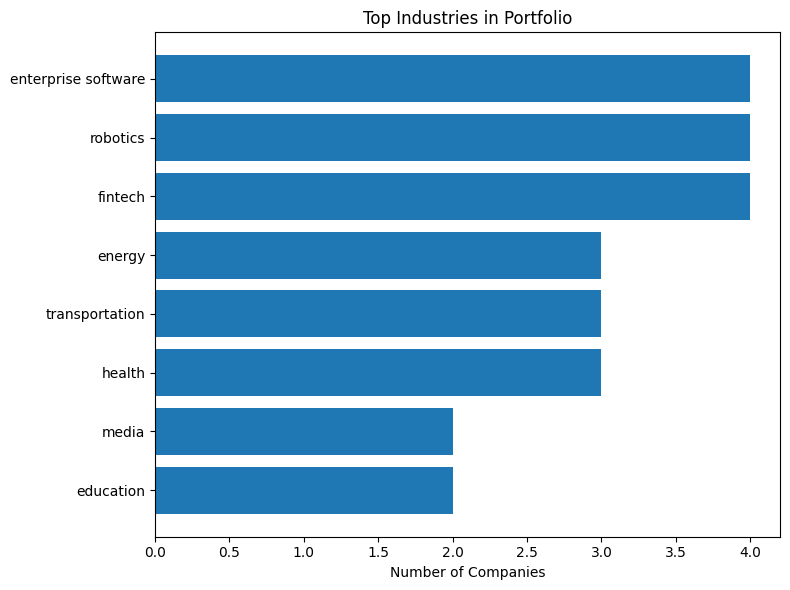

In [15]:
top_sectors = sector_counts.sort_values(ascending=False).head(8)

plt.figure(figsize=(8,6))
plt.barh(top_sectors.index[::-1], top_sectors.values[::-1])
plt.xlabel("Number of Companies")
plt.title("Top Industries in Portfolio")
plt.tight_layout()
plt.show()

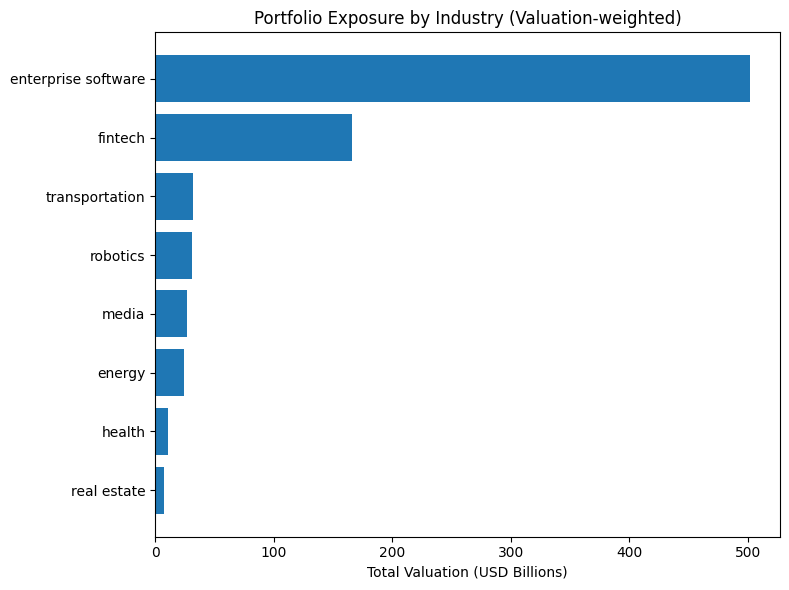

In [16]:
industry_funding = df_exploded.groupby("Industries_list")["Valuation_B"].sum()
industry_funding = industry_funding.sort_values(ascending=False).head(8)

plt.figure(figsize=(8,6))
plt.barh(industry_funding.index[::-1], industry_funding.values[::-1])
plt.xlabel("Total Valuation (USD Billions)")
plt.title("Portfolio Exposure by Industry (Valuation-weighted)")
plt.tight_layout()
plt.show()

In [19]:
import plotly.express as px

fig = px.bar(
    sector_counts.reset_index(),
    x="Industries_list",
    y="count",
    title="Portfolio Distribution by Industry",
    color="Industries_list" # Questo aggiunge ancora un colore, ma nasconderemo la legenda
)

# Nasconde la legenda del colore
fig.update_layout(showlegend=False)

# Regola le etichette dell'asse X
fig.update_xaxes(
    tickangle=0, # Rende le etichette orizzontali
    automargin=True, # Adatta automaticamente i margini per evitare sovrapposizioni
    tickfont=dict(size=10) # Puoi regolare la dimensione del font se necessario
)

fig.show()

In [20]:
import plotly.express as px
import plotly.graph_objects as go

In [21]:
industry_valuation = (
    df_exploded
    .groupby("Industries_list")["Valuation_B"]
    .sum()
    .reset_index()
    .sort_values("Valuation_B", ascending=False)
)

fig = px.bar(
    industry_valuation.head(10),
    x="Valuation_B",
    y="Industries_list",
    orientation="h",
    title="Portfolio Exposure by Industry (Valuation-weighted)",
    labels={"Valuation_B": "Total Valuation (USD Billions)",
            "Industries_list": "Industry"}
)

fig.update_layout(template="plotly_white")
fig.show()

In [33]:
import plotly.express as px
import pandas as pd


industry_valuation = industry_valuation.sort_values("Valuation_B", ascending=True)

fig = px.bar(
    industry_valuation,
    x="Valuation_B",
    y="Industries_list",
    orientation="h",
    color="Valuation_B",
    color_continuous_scale=[
        "#E0F3F8",
        "#ABD9E9",
        "#74ADD1",
        "#4575B4",
        "#313695"
    ],
    text=industry_valuation["Valuation_B"].round(1)
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    coloraxis_showscale=False,
    title_font_size=24,
    title_x=0.5,
    font=dict(size=14),
    xaxis_title="Total Valuation (USD Billions)",
    yaxis_title="",
    plot_bgcolor="white",
    margin=dict(l=120, r=40, t=80, b=40)
)

fig.show()

In [34]:
import plotly.express as px
import pandas as pd

# Ordiniamo correttamente
industry_valuation = industry_valuation.sort_values("Valuation_B", ascending=True)

fig = px.bar(
    industry_valuation,
    x="Valuation_B",
    y="Industries_list",
    orientation="h",
    color="Valuation_B",
    color_continuous_scale="Viridis",   # palette elegante
    text=industry_valuation["Valuation_B"].round(1),
    title="Portfolio Exposure by Industry (Valuation-weighted)"
)

fig.update_traces(
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    coloraxis_showscale=False,
    title_font_size=24,
    title_x=0.5,
    font=dict(size=14),
    xaxis_title="Total Valuation (USD Billions)",
    yaxis_title="",
    plot_bgcolor="white",
    margin=dict(l=120, r=40, t=80, b=40)
)

fig.show()

In [32]:
fig = px.bar(
    industry_valuation,
    x="Valuation_B",
    y="Industries_list",
    orientation="h",
    color="Valuation_B",
    color_continuous_scale=[
        "#E0F3F8",
        "#ABD9E9",
        "#74ADD1",
        "#4575B4",
        "#313695"
    ],
    text=industry_valuation["Valuation_B"].round(1)
)

In [22]:
fig = px.scatter(
    df,
    x="Funding_B",
    y="Valuation_B",
    size="Employees latest number",
    color="HQ country",
    hover_name="Name",
    title="Funding vs Valuation (Bubble size = Employees)",
    labels={
        "Funding_B": "Total Funding (USD Billions)",
        "Valuation_B": "Valuation (USD Billions)"
    }
)

fig.update_layout(template="plotly_white")
fig.show()

In [23]:
stage_counts = (
    df["Last round"]
    .value_counts()
    .reset_index()
)

stage_counts.columns = ["Last round", "Count"]

fig = px.bar(
    stage_counts,
    x="Last round",
    y="Count",
    title="Portfolio Distribution by Last Funding Round"
)

fig.update_layout(template="plotly_white")
fig.show()

In [24]:
fig = px.histogram(
    df,
    x="Launch year",
    nbins=10,
    title="Portfolio Company Founding Year Distribution"
)

fig.update_layout(template="plotly_white")
fig.show()

In [25]:
geo_counts = (
    df["HQ country"]
    .value_counts()
    .reset_index()
)

geo_counts.columns = ["HQ country", "Count"]

fig = px.bar(
    geo_counts,
    x="HQ country",
    y="Count",
    title="Portfolio Distribution by HQ Country"
)

fig.update_layout(template="plotly_white")
fig.show()

In [27]:
import plotly.express as px

fig = px.sunburst(
    df_exploded,
    path=["Industries_list", "Last round"],
    values="Valuation_B",
    color="Industries_list",
    title="Sam Altman Portfolio Mapping"
)

fig.update_layout(template="plotly_white")
fig.show()

In [35]:
def classify_sector(row):
    industry = str(row["Industries"]).lower()
    sub = str(row["Sub industries"]).lower()

    text = industry + " " + sub

    if any(k in text for k in ["artificial intelligence", "ai", "machine learning"]):
        return "AI & Machine Learning"

    elif "fintech" in text or "payments" in text:
        return "Fintech"

    elif any(k in text for k in ["energy", "robotics", "engineering", "transportation", "space"]):
        return "Deep Tech & Energy"

    elif "enterprise software" in text:
        return "Enterprise Software"

    elif any(k in text for k in ["media", "consumer", "education"]):
        return "Consumer & Media"

    elif "real estate" in text:
        return "Real Estate"

    else:
        return "Other"

In [36]:
df["Strategic Sector"] = df.apply(classify_sector, axis=1)

In [37]:
sector_exposure = (
    df.groupby("Strategic Sector")["Valuation_B"]
    .sum()
    .reset_index()
    .sort_values("Valuation_B", ascending=True)
)

In [38]:
import plotly.express as px

fig = px.bar(
    sector_exposure,
    x="Valuation_B",
    y="Strategic Sector",
    orientation="h",
    color="Valuation_B",
    color_continuous_scale="Plasma",
    text=sector_exposure["Valuation_B"].round(1),
    title="Sam Altman Portfolio – Strategic Allocation (Valuation-weighted)"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    template="plotly_white",
    coloraxis_showscale=False,
    title_font_size=24,
    title_x=0.5,
    xaxis_title="Total Valuation (USD Billions)",
    yaxis_title="",
    font=dict(size=14),
    margin=dict(l=100, r=40, t=80, b=40)
)

fig.show()

In [56]:
import plotly.express as px

employees_df = df.sort_values("Employees latest number", ascending=False)

fig = px.bar(
    employees_df,
    x="Employees latest number",
    y="Name",
    orientation="h",
    title="Portfolio Companies by Employees"
)

fig.update_traces(marker_color="#1f77b4")

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    xaxis_title="Number of Employees",
    yaxis_title="",
    height=800,
    yaxis=dict(autorange="reversed")
)

fig.show()

In [57]:
import plotly.express as px

# Convertiamo funding in miliardi per coerenza visiva
df["Funding_B"] = df["Total funding (USD M)"] / 1000

funding_df = df.sort_values("Funding_B", ascending=False)

fig = px.bar(
    funding_df,
    x="Funding_B",
    y="Name",
    orientation="h",
    title="Portfolio Companies by Total Funding"
)

fig.update_traces(marker_color="#1f77b4")

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    xaxis_title="Total Funding (USD Billions)",
    yaxis_title="",
    height=800,
    yaxis=dict(autorange="reversed")
)

fig.show()

In [58]:
df["Funding_B"] = df["Total funding (USD M)"] / 1000

In [59]:
import pandas as pd

comparison_df = df[["Name", "Valuation_B", "Funding_B"]].copy()

comparison_long = comparison_df.melt(
    id_vars="Name",
    value_vars=["Valuation_B", "Funding_B"],
    var_name="Metric",
    value_name="USD_Billions"
)

# Ordiniamo per valuation
order = comparison_df.sort_values("Valuation_B", ascending=False)["Name"]
comparison_long["Name"] = pd.Categorical(
    comparison_long["Name"],
    categories=order,
    ordered=True
)

In [60]:
import plotly.express as px

fig = px.bar(
    comparison_long,
    x="USD_Billions",
    y="Name",
    color="Metric",
    orientation="h",
    barmode="group",
    title="Funding vs Valuation Comparison"
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    xaxis_title="USD Billions",
    yaxis_title="",
    height=800,
    yaxis=dict(autorange="reversed")
)

fig.show()